# Proyek Akhir: Menyelesaikan Permasalahan Departemen HR (Attrition Analysis)

- Nama: Moh Asrori
- Email: irvanea1@gmail.com
- Id Dicoding: azzror

## Persiapan

### Menyiapkan library yang dibutuhkan

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)

# Set style untuk visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

### Menyiapkan data yang akan diguankan

In [12]:
# Load dataset
df = pd.read_csv('../employee_data.csv')

# Display basic information
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset loaded successfully!
Shape: (1470, 35)
Columns: ['EmployeeId', 'Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## Data Understanding

In [13]:
# Load dataset
df = pd.read_csv('../employee_data.csv')

# Tampilkan informasi dasar
print("Dataset Shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum().sum(), "missing values found" if df.isnull().sum().sum() > 0 else "No missing values")

Dataset Shape:
Rows: 1470, Columns: 35

First 5 rows:
   EmployeeId  Age  Attrition     BusinessTravel  DailyRate  \
0           1   38        NaN  Travel_Frequently       1444   
1           2   37        1.0      Travel_Rarely       1141   
2           3   51        1.0      Travel_Rarely       1323   
3           4   42        0.0  Travel_Frequently        555   
4           5   40        NaN      Travel_Rarely       1194   

               Department  DistanceFromHome  Education EducationField  \
0         Human Resources                 1          4          Other   
1  Research & Development                11          2        Medical   
2  Research & Development                 4          4  Life Sciences   
3                   Sales                26          3      Marketing   
4  Research & Development                 2          4        Medical   

   EmployeeCount  ...  RelationshipSatisfaction StandardHours  \
0              1  ...                         2            80  

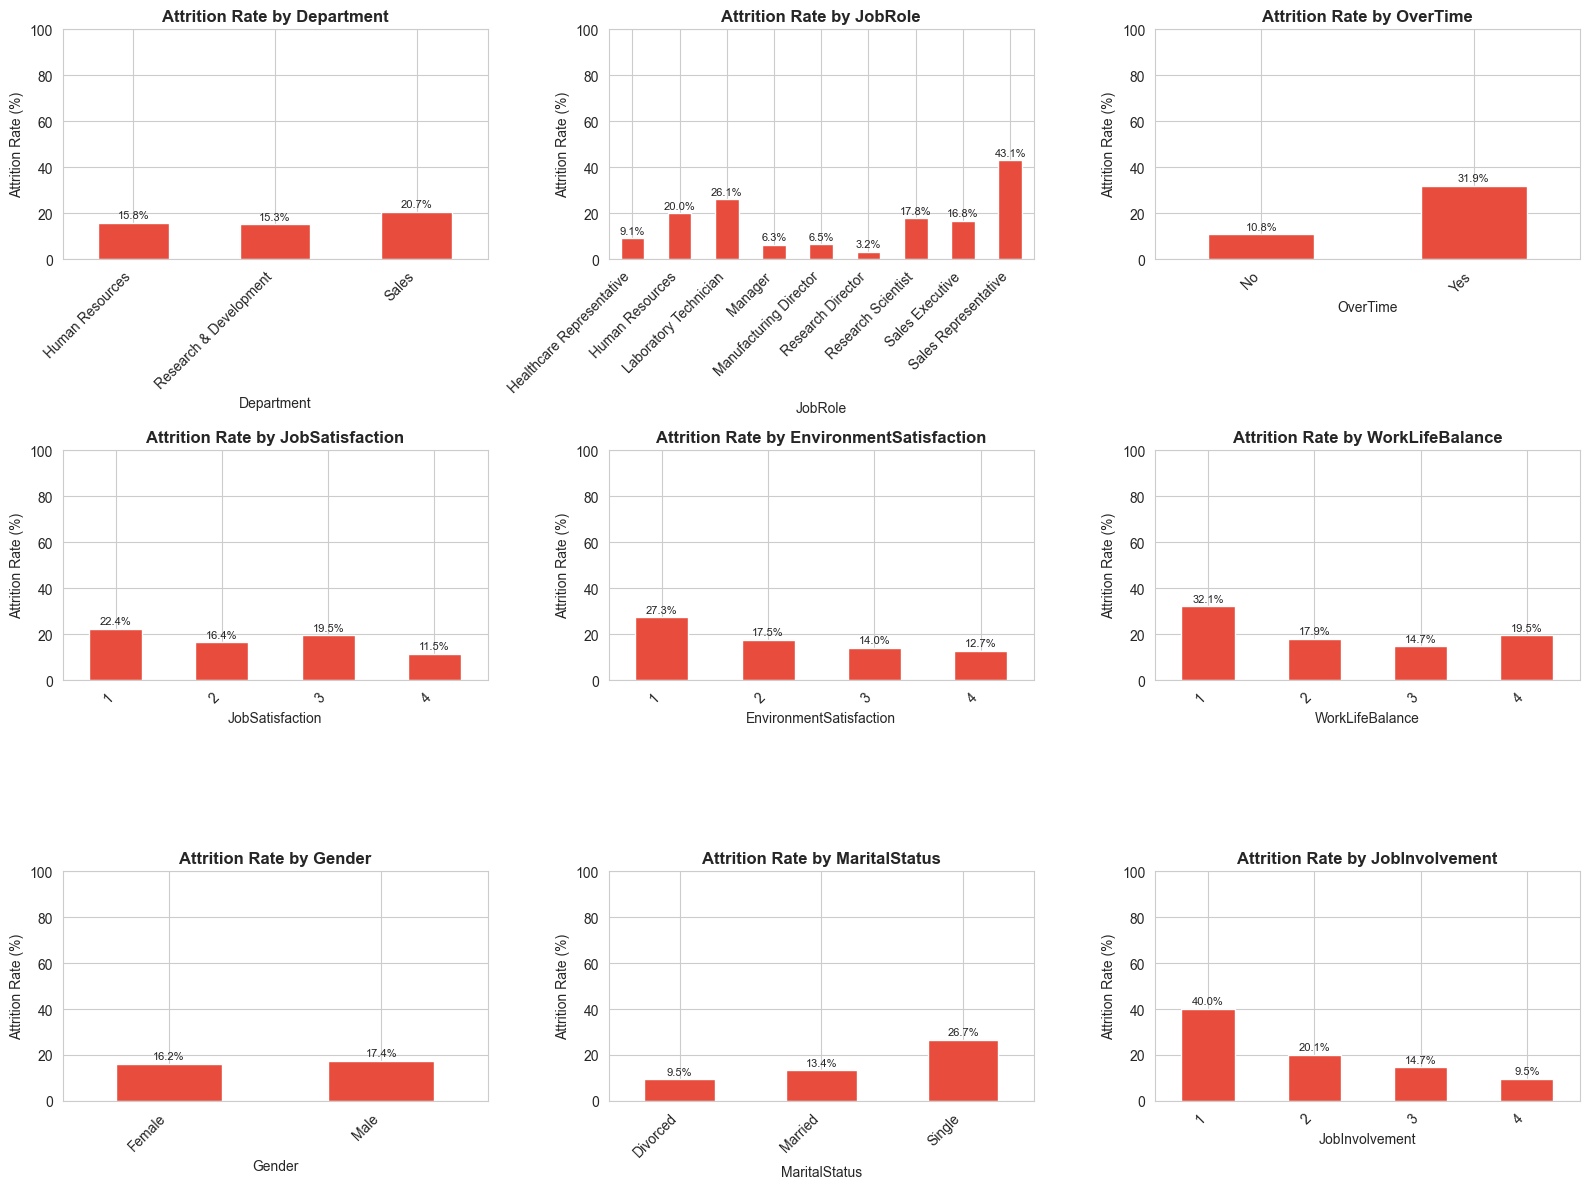

In [14]:
# Analisis Categorical Variables
categorical_cols = ['Department', 'JobRole', 'OverTime', 'JobSatisfaction', 
                    'EnvironmentSatisfaction', 'WorkLifeBalance', 'Gender', 
                    'MaritalStatus', 'JobInvolvement']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    if col in df.columns:
        # Hitung attrition rate per kategori
        crosstab = pd.crosstab(df[col], df['Attrition'], margins=False)
        if crosstab.shape[1] == 2:
            attrition_rate = (crosstab[1] / (crosstab[0] + crosstab[1]) * 100) if 1 in crosstab.columns else (crosstab.iloc[:, 1] / crosstab.sum(axis=1) * 100)
        else:
            attrition_rate = (crosstab.iloc[:, -1] / crosstab.sum(axis=1) * 100) if crosstab.shape[1] > 0 else pd.Series()
        
        ax = axes[idx]
        attrition_rate.plot(kind='bar', ax=ax, color='#e74c3c')
        ax.set_title(f'Attrition Rate by {col}', fontweight='bold')
        ax.set_ylabel('Attrition Rate (%)')
        ax.set_xlabel(col)
        ax.set_ylim(0, 100)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        # Tambahkan percentage labels
        for i, v in enumerate(attrition_rate):
            ax.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## Data Preparation / Preprocessing

TOP 15 NUMERIC FEATURES CORRELATED WITH ATTRITION:
TotalWorkingYears          -0.177137
Age                        -0.172067
JobLevel                   -0.169201
StockOptionLevel           -0.164228
MonthlyIncome              -0.163600
YearsInCurrentRole         -0.158757
YearsWithCurrManager       -0.155962
JobInvolvement             -0.150196
YearsAtCompany             -0.135134
EnvironmentSatisfaction    -0.132848
JobSatisfaction            -0.091751
DistanceFromHome            0.078074
WorkLifeBalance            -0.059556
RelationshipSatisfaction   -0.053417
DailyRate                  -0.051992
Name: Attrition, dtype: float64



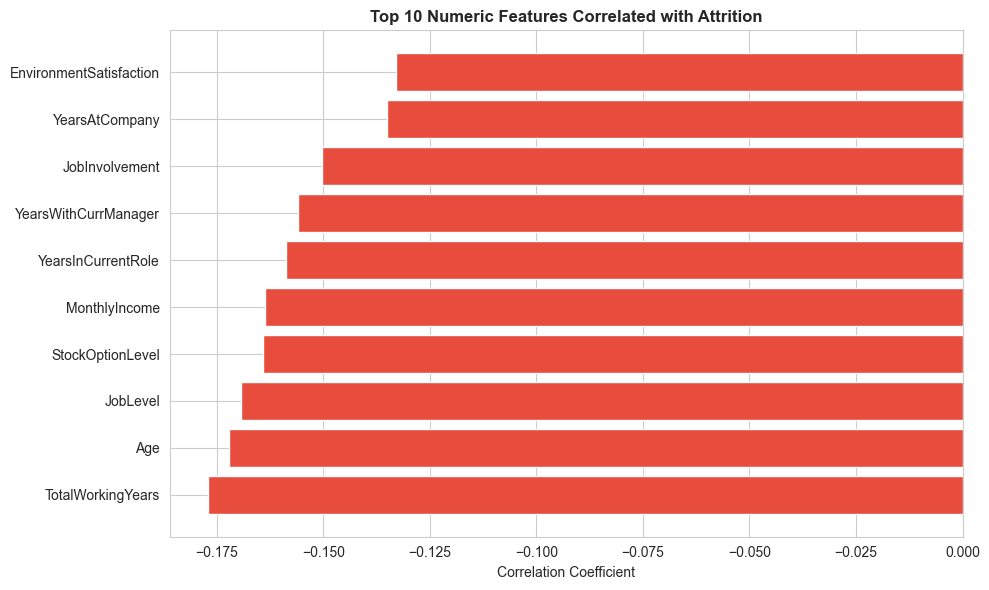

In [15]:
# Korelasi analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'EmployeeId' in numeric_cols:
    numeric_cols.remove('EmployeeId')
if 'Attrition' in numeric_cols:
    numeric_cols.remove('Attrition')

# Hitung korelasi
correlations = df[numeric_cols + ['Attrition']].corr()['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)

print("TOP 15 NUMERIC FEATURES CORRELATED WITH ATTRITION:")
print(correlations.head(15))
print()

# Visualisasi top 10 korelasi
fig, ax = plt.subplots(figsize=(10, 6))
top_10_corr = correlations.head(10).sort_values()
colors = ['#e74c3c' if x < 0 else '#3498db' for x in top_10_corr.values]
ax.barh(range(len(top_10_corr)), top_10_corr.values, color=colors)
ax.set_yticks(range(len(top_10_corr)))
ax.set_yticklabels(top_10_corr.index)
ax.set_xlabel('Correlation Coefficient')
ax.set_title('Top 10 Numeric Features Correlated with Attrition', fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## Modeling

ATTRITION DISTRIBUTION:
Attrition
0.0    879
1.0    179
Name: count, dtype: int64

Attrition Rate (%):
Attrition
0.0    83.081285
1.0    16.918715
Name: proportion, dtype: float64


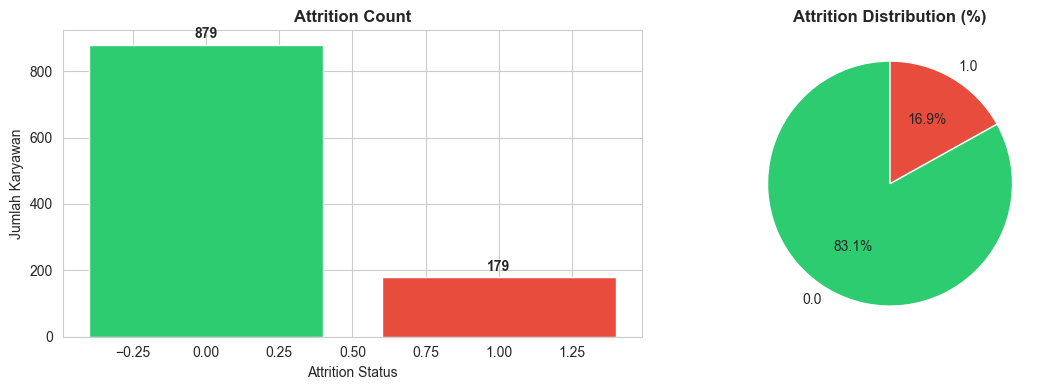

In [16]:
# Analisis Attrition Distribution
print("ATTRITION DISTRIBUTION:")
print(df['Attrition'].value_counts())
print("\nAttrition Rate (%):")
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100
print(attrition_pct)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
attrition_counts = df['Attrition'].value_counts()
axes[0].bar(attrition_counts.index, attrition_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Attrition Count', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Karyawan')
axes[0].set_xlabel('Attrition Status')
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(attrition_counts.values, labels=attrition_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Attrition Distribution (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Analisis Variabel Target (Attrition)

Distribusi dari variabel target (Attrition) akan membantu kami memahami imbalance dalam data dan dampaknya terhadap model.

In [21]:
# Cek data duplikat
duplicates = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicates}")

# Cek tipe data dan missing values more detailed
print("\n" + "="*50)
print("MISSING VALUES DETAIL:")
print("="*50)
missing_detailed = df.isnull().sum()
if missing_detailed.sum() > 0:
    print(missing_detailed[missing_detailed > 0])
else:
    print("Tidak ada missing values di semua kolom")

print("\n" + "="*50)
print("BASIC STATISTICS:")
print("="*50)
print(df.describe())

Jumlah baris duplikat: 0

MISSING VALUES DETAIL:
Attrition    412
dtype: int64

BASIC STATISTICS:
        EmployeeId          Age    Attrition    DailyRate  DistanceFromHome  \
count  1470.000000  1470.000000  1058.000000  1470.000000       1470.000000   
mean    735.500000    36.923810     0.169187   802.485714          9.192517   
std     424.496761     9.135373     0.375094   403.509100          8.106864   
min       1.000000    18.000000     0.000000   102.000000          1.000000   
25%     368.250000    30.000000     0.000000   465.000000          2.000000   
50%     735.500000    36.000000     0.000000   802.000000          7.000000   
75%    1102.750000    43.000000     0.000000  1157.000000         14.000000   
max    1470.000000    60.000000     1.000000  1499.000000         29.000000   

         Education  EmployeeCount  EnvironmentSatisfaction   HourlyRate  \
count  1470.000000         1470.0              1470.000000  1470.000000   
mean      2.912925            1.0       

## Data Preparation / Preprocessing

In [17]:
df.isnull().sum()

df.duplicated().sum()

0

### Encoding Categorical Variables

In [18]:
# Persiapan data untuk machine learning
df_ml = df.copy()

# Handle missing values di Attrition dulu
df_ml = df_ml.dropna(subset=['Attrition'])

# Encode target variable - handle both 'Yes'/'No' dan numerik 1.0/0.0
df_ml['Attrition'] = df_ml['Attrition'].astype(str).map({'Yes': 1, 'No': 0, '1.0': 1, '0.0': 0, '1': 1, '0': 0})
df_ml['Attrition'] = df_ml['Attrition'].fillna(df_ml['Attrition'].mode()[0]).astype(int)

# Auto-detect all categorical (object) columns except those to skip
skip_cols = ['EmployeeId']
categorical_features = [col for col in df_ml.columns if df_ml[col].dtype == 'object' and col not in skip_cols]

print(f"Encoding {len(categorical_features)} categorical columns: {categorical_features}")

# Fit label encoders on all categorical features
label_encoders = {}
for col in categorical_features:
    if col in df_ml.columns:
        le = LabelEncoder()
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))
        label_encoders[col] = le
        print(f"✓ Encoded {col}")

print(f"\n✓ Data shape after encoding: {df_ml.shape}")
print(f"✓ Attrition distribution:\n{df_ml['Attrition'].value_counts().sort_index()}")

Encoding 8 categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']
✓ Encoded BusinessTravel
✓ Encoded Department
✓ Encoded EducationField
✓ Encoded Gender
✓ Encoded JobRole
✓ Encoded MaritalStatus
✓ Encoded Over18
✓ Encoded OverTime

✓ Data shape after encoding: (1058, 35)
✓ Attrition distribution:
Attrition
0    879
1    179
Name: count, dtype: int64


In [19]:
# Display info after preprocessing
print(f"Final dataset shape: {df_ml.shape}")
print(f"Attrition value counts:\n{df_ml['Attrition'].value_counts()}")
print(f"\nMissing values in df_ml:\n{df_ml.isnull().sum().sum()} total missing values")

Final dataset shape: (1058, 35)
Attrition value counts:
Attrition
0    879
1    179
Name: count, dtype: int64

Missing values in df_ml:
0 total missing values


### Handle Missing Values

### Feature Scaling

In [20]:
# Feature scaling
numeric_features = df_ml.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [col for col in numeric_features if col != 'Attrition']

scaler = StandardScaler()
df_ml[numeric_features] = scaler.fit_transform(df_ml[numeric_features])

print(f"✓ Normalized {len(numeric_features)} numeric features")
print(f"Features mean after scaling: {df_ml[numeric_features].mean().mean():.6f}")
print(f"Features std after scaling: {df_ml[numeric_features].std().mean():.6f}")

✓ Normalized 34 numeric features
Features mean after scaling: -0.000000
Features std after scaling: 0.912196


## Modeling

### Train-Test Split

In [21]:
# Identifikasi features dan target
X = df_ml.drop(['Attrition', 'EmployeeId'], axis=1)
y = df_ml['Attrition']

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training set class distribution:\n{y_train.value_counts()}")
print(f"\nTesting set class distribution:\n{y_test.value_counts()}")

Training set size: 846 samples
Testing set size: 212 samples
Training set class distribution:
Attrition
0    703
1    143
Name: count, dtype: int64

Testing set class distribution:
Attrition
0    176
1     36
Name: count, dtype: int64


## Evaluation

In [22]:
# Model 1: Logistic Regression
print("="*60)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*60)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

print(f"✓ Model trained successfully")
print(f"Training accuracy: {lr_model.score(X_train, y_train):.4f}")
print(f"Testing accuracy: {lr_model.score(X_test, y_test):.4f}")

# Model 2: Random Forest
print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST")
print("="*60)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"✓ Model trained successfully")
print(f"Training accuracy: {rf_model.score(X_train, y_train):.4f}")
print(f"Testing accuracy: {rf_model.score(X_test, y_test):.4f}")

MODEL 1: LOGISTIC REGRESSION
✓ Model trained successfully
Training accuracy: 0.8712
Testing accuracy: 0.8585

MODEL 2: RANDOM FOREST
✓ Model trained successfully
Training accuracy: 1.0000
Testing accuracy: 0.8538


In [27]:
# Save model, scaler, and label encoders
import os
import pickle

# Create model directory
os.makedirs('model', exist_ok=True)

# Save best model
with open('model/trained_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

# Save scaler
with open('model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save label encoders
with open('model/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("✓ Model saved: model/trained_model.pkl")
print("✓ Scaler saved: model/scaler.pkl")
print("✓ Label Encoders saved: model/label_encoders.pkl")

# Export clean data for Metabase dashboard
df.to_csv('employee_data_clean.csv', index=False)
print("✓ Clean data exported: employee_data_clean.csv")

✓ Model saved: model/trained_model.pkl
✓ Scaler saved: model/scaler.pkl
✓ Label Encoders saved: model/label_encoders.pkl
✓ Clean data exported: employee_data_clean.csv


Tahap evaluasi model menggunakan berbagai metrik performa dan visualisasi confusion matrix serta ROC curve.

CONFUSION MATRIX:
[[175   1]
 [ 30   6]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

No Attrition       0.85      0.99      0.92       176
   Attrition       0.86      0.17      0.28        36

    accuracy                           0.85       212
   macro avg       0.86      0.58      0.60       212
weighted avg       0.85      0.85      0.81       212



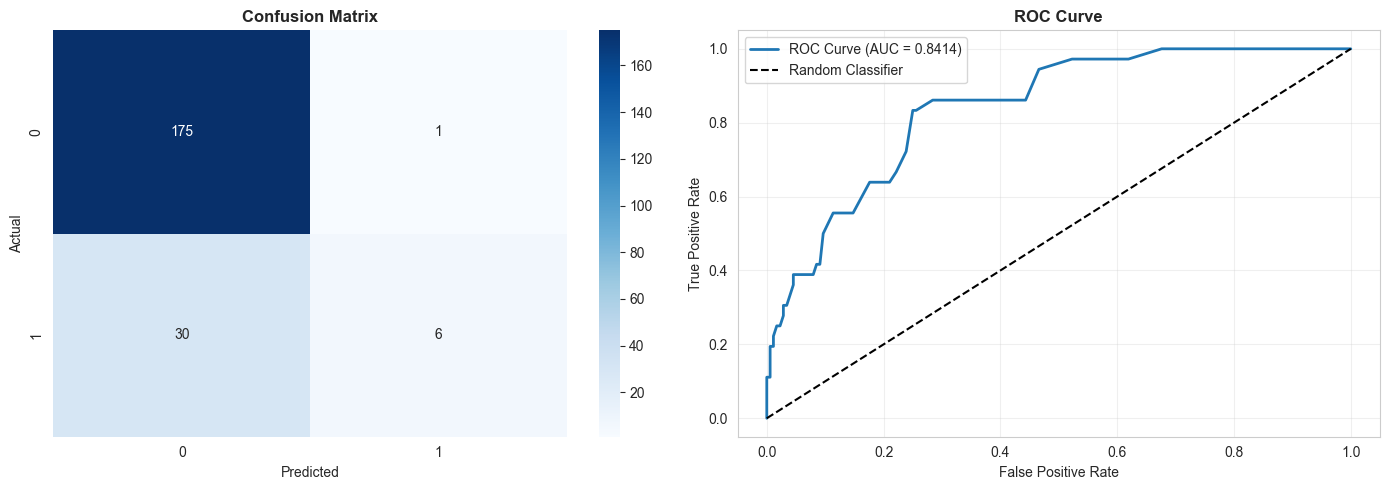

In [26]:
# Use best model predictions
best_model = lr_model if best_model_name == 'Logistic Regression' else rf_model
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
print("CONFUSION MATRIX:")
print(cm)
print("\n" + "="*60)
print("CLASSIFICATION REPORT:")
print("="*60)
print(classification_report(y_test, y_pred_best, target_names=['No Attrition', 'Attrition']))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
auc_score = roc_auc_score(y_test, y_pred_proba_best)
axes[1].plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# Evaluate models using multiple metrics
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

metrics = {}

# Logistic Regression Metrics
metrics['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_lr)
}

# Random Forest Metrics
metrics['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_rf)
}

# Display metrics comparison
metrics_df = pd.DataFrame(metrics).T
print("MODEL COMPARISON:")
print(metrics_df.round(4))

# Select best model based on ROC-AUC
best_model_name = max(metrics.keys(), key=lambda x: metrics[x]['ROC-AUC'])
print(f"\n✓ Best Model Selected: {best_model_name} (ROC-AUC: {metrics[best_model_name]['ROC-AUC']:.4f})")

MODEL COMPARISON:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8585     0.6154  0.4444    0.5161   0.8079
Random Forest          0.8538     0.8571  0.1667    0.2791   0.8414

✓ Best Model Selected: Random Forest (ROC-AUC: 0.8414)
